In [7]:
%cd ..

/home/v1adych/projects/kolobok


In [21]:
from pathlib import Path

import torch
import cv2

from matplotlib import pyplot as plt    

In [24]:
root = Path("data/sample")

imgs = [cv2.imread(str(p)) for p in sorted(root.glob("*.jpg"))]

In [25]:
cv2.Canny(imgs[3], 100, 200)[..., None].max() / 255

np.float64(1.0)

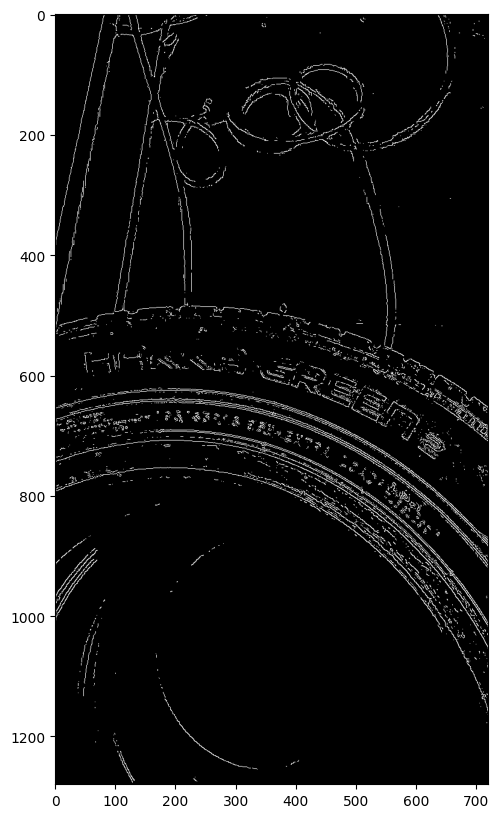

In [35]:
plt.figure(figsize=(10, 10))
plt.imshow(cv2.Canny(imgs[3], 100, 100)[..., None] / 255 , cmap="gray")

In [8]:
import cv2
import numpy as np
import subprocess
import json
import os

# === CONFIGURATION ===
num = 1
original_image_path = f"../data/sample/tyre{num}.jpg"
rotated_image_template = "../data/gen/rotated_{angle}.jpg"
output_json_path = "../data/out/preds/rotated_{angle}.json"  # default output filename
config_path = "../mmocr/configs/textdet/panet/panet_resnet18_fpem-ffm_600e_ctw1500.py"
weights_path = "../weights/panet_resnet18_fpem-ffm_600e_ctw1500_20220826_144818-980f32d0.pth"
out_dir = "../data/out"
rotation_angles = range(-90, 90, 10)  # from -10 to +10 degrees
accumulated_output = "../data/out/accumulated_polygons.json"

# === LOAD ORIGINAL IMAGE ===
img = cv2.imread(original_image_path)
if img is None:
    raise FileNotFoundError(f"Image not found: {original_image_path}")

(h, w) = img.shape[:2]
center = (w // 2, h // 2)
all_polygons = []

# === MAIN LOOP ===
for angle in rotation_angles:
    print(f"[INFO] Processing angle {angle}°")
    
    # Rotate image
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(img, M, (w, h))
    rotated_path = rotated_image_template.format(angle=angle)
    cv2.imwrite(rotated_path, rotated)

    # Run detection
    cmd = [
        "python", "../mmocr/tools/infer.py", rotated_path,
        "--det", config_path,
        "--print-result",
        "--out-dir", out_dir,
        "--save_pred",
        "--det-weights", weights_path
    ]
    subprocess.run(cmd, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

    # Load detection result
    # Load detection result (your format has a nested structure)
    try:
        with open(output_json_path.format(angle=angle), "r") as f:
            result = json.load(f)
            polygons = result["det_polygons"]
            
            for poly in polygons:
                # Group every 2 floats as a point
                points = [(poly[i], poly[i+1]) for i in range(0, len(poly), 2)]
                
                # Inverse transform points
                M_inv = cv2.invertAffineTransform(M)
                corrected = []
                for x, y in points:
                    px = M_inv[0, 0]*x + M_inv[0, 1]*y + M_inv[0, 2]
                    py = M_inv[1, 0]*x + M_inv[1, 1]*y + M_inv[1, 2]
                    corrected.append([px, py])
                all_polygons.append(corrected)
    except Exception as e:
        print(f"[WARN] Could not load or parse detection for angle {angle}: {e}")

# === SAVE RESULTS ===
os.makedirs(os.path.dirname(accumulated_output), exist_ok=True)
with open(accumulated_output, "w") as f:
    json.dump(all_polygons, f, indent=2)

print(f"[DONE] Accumulated {len(all_polygons)} polygons into {accumulated_output}")

vis_image = img.copy()

for poly in all_polygons:
    pts = np.array(poly, np.int32).reshape((-1, 1, 2))
    cv2.polylines(vis_image, [pts], isClosed=True, color=(0, 255, 0), thickness=2)

# Save visualization
vis_path = "../data/out/accumulated_polygons_visualized.jpg"
cv2.imwrite(vis_path, vis_image)
print(f"[DONE] Saved visualization to {vis_path}")

[INFO] Processing angle -90°
[INFO] Processing angle -80°
[INFO] Processing angle -70°
[INFO] Processing angle -60°
[INFO] Processing angle -50°
[INFO] Processing angle -40°
[INFO] Processing angle -30°
[INFO] Processing angle -20°
[INFO] Processing angle -10°
[INFO] Processing angle 0°
[INFO] Processing angle 10°
[INFO] Processing angle 20°
[INFO] Processing angle 30°
[INFO] Processing angle 40°
[INFO] Processing angle 50°
[INFO] Processing angle 60°
[INFO] Processing angle 70°
[INFO] Processing angle 80°
[DONE] Accumulated 139 polygons into ../data/out/accumulated_polygons.json
[DONE] Saved visualization to ../data/out/accumulated_polygons_visualized.jpg


In [11]:
import cv2
import numpy as np
import json
from shapely.geometry import Polygon
from shapely.ops import unary_union

# === CONFIGURATION ===
image_path = f"../data/sample/tyre{num}.jpg"
polygon_path = "../data/out/accumulated_polygons.json"
output_path = "../data/out/vis/merged_polygons_visualized.jpg"

# === LOAD IMAGE ===
img = cv2.imread(image_path)
if img is None:
    raise FileNotFoundError(f"Image not found: {image_path}")
vis_image = img.copy()

# === LOAD POLYGONS ===
with open(polygon_path, "r") as f:
    all_polygons = json.load(f)

# === CONVERT & MERGE USING SHAPELY ===
shapely_polygons = []
for poly in all_polygons:
    try:
        polygon = Polygon(poly)
        if polygon.is_valid:
            shapely_polygons.append(polygon)
    except Exception:
        continue

merged = unary_union(shapely_polygons)

# === EXTRACT MERGED SHAPE(S) ===
if merged.geom_type == 'Polygon':
    merged_polygons = [list(merged.exterior.coords)]
elif merged.geom_type == 'MultiPolygon':
    merged_polygons = [list(p.exterior.coords) for p in merged.geoms]
else:
    merged_polygons = []

# === DRAW MERGED POLYGONS ===
for poly in merged_polygons:
    pts = np.array(poly, np.int32).reshape((-1, 1, 2))
    cv2.polylines(vis_image, [pts], isClosed=True, color=(0, 0, 255), thickness=3)

# === SAVE OUTPUT ===
cv2.imwrite(output_path, vis_image)
print(f"[DONE] Saved merged visualization to: {output_path}")


[DONE] Saved merged visualization to: ../data/out/vis/merged_polygons_visualized.jpg
